# Tiny Dreamer Highway — Final Run

**Name:** Esteban Montelongo | **Course:** CSC 580 AI 2 | **Assignment:** Final Project — Dream the Road | **AI tools:** GitHub Copilot

---

This notebook trains and evaluates a **DreamerV1** continuous-control agent on `highway-v0`.

DreamerV1 separates world-model learning from policy learning: the RSSM (Recurrent State-Space Model) learns a compressed latent representation of the environment from pixel observations, then the actor-critic is trained entirely inside imagined latent rollouts — never touching the real environment during policy updates. See the project report for full algorithm derivations.

## Experiment Design

| Phase | Environment | Config | Purpose |
|-------|-------------|--------|---------|
| **A — training** | 4 lanes, 28 cars | `final_run.yaml` | Learn a speed-maximising continuous-control policy |
| **B — showcase** | 6 lanes, 45 cars | `final_showcase_eval.yaml` | Evaluate trained weights in denser, wider traffic |

**Sections:** Setup → Config → Training → Training curves → N-step prediction eval → Driving demos → Submission bundle

## 1 · Environment Setup

Mount Drive for artifact persistence (Colab VMs are ephemeral — everything under `/content/` is lost on disconnect), then clone/update the repo and install the package in editable mode so imports resolve from source.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

print('Drive root:', DRIVE_ROOT)
print('Artifact root:', ARTIFACT_ROOT)

Mounted at /content/drive
Drive root: /content/drive/MyDrive/CSC_580_Final_Project
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
BRANCH='GrandpaDrivers'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone -b "${BRANCH}" "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git fetch origin "${BRANCH}"
  git checkout "${BRANCH}"
  git pull --ff-only origin "${BRANCH}"
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.3 MB/s eta 0:00:00


Cloning into '/content/CSC_580_Final_Project'...


## 2 · Experiment Configuration

Key choices in `final_run.yaml` and their rationale:

| Setting | Value | Why |
|---------|-------|-----|
| `lanes_count` | 4 | Project requirement (minimum 4) |
| `vehicles_count` | 28 | Moderately hard — enough traffic to require overtaking without overwhelming random resets during warm-start |
| `high_speed_reward` | 0.7 | Strong speed signal — raised from 0.5 so the agent actively overtakes rather than trailing slower traffic |
| `right_lane_reward` | 0.0 | Zero — any positive value creates a degenerate "lane-hugger" policy that ignores speed |
| `reward_speed_range` | [20, 35] | Higher upper bound keeps the reward gradient active at faster cruising speeds |
| `steering_penalty` | 0.0075 | Slightly lower than baseline, but not so low that lane changes become twitchy |
| `steering_change_penalty` | 0.02 | Reduced more conservatively to allow overtaking without inviting oscillation |
| `max_episode_steps` | 75 | Extended from 50 — gives the agent more runway to build speed after a lane change |
| `imagination_horizon` | 20 | Long enough for multi-step lane-change credit assignment; beyond ~25 steps RSSM drift degrades λ-return estimates |
| `free_nats` | 3.0 | Prevents posterior collapse early in training by ignoring KL below this threshold |
| `use_amp` / `bfloat16` | true | H100 tensor-core throughput; bfloat16 preserves fp32 exponent range, safe for KL spikes |
| `batch_size` / updates | 256 / 16 | Large batches keep world-model and behavior updates stable on H100 hardware |

In [ ]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

# Phase-A training config — tuned for aggressive, fast continuous control
CONFIG_PATH = PROJECT_ROOT / 'examples' / 'final_run.yaml'
config = load_experiment_config(CONFIG_PATH)

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'
print('Loaded config from:', CONFIG_PATH)
print('GPU:', gpu_name)
if 'H100' not in gpu_name:
    print('Note: config is optimised for H100 but will run on any CUDA device.')

print('\n--- Environment ---')
print('Action type:', config.env.action.type)
print('Lanes count:', config.env.lanes_count)
print('Vehicles count:', config.env.vehicles_count)
print('Max episode steps:', config.env.max_episode_steps)

print('\n--- Reward shaping ---')
print('high_speed_reward:', config.env.reward.high_speed_reward)
print('right_lane_reward:', config.env.reward.right_lane_reward)
print('reward_speed_range:', config.env.reward.reward_speed_range)
print('offroad_terminal:', config.env.reward.offroad_terminal)

print('\n--- Training knobs ---')
print('grad_clip_norm:', config.training.grad_clip_norm)
print('lr_warmup_steps:', config.training.lr_warmup_steps)
print('use_amp:', config.training.use_amp, f'({config.training.amp_dtype})')
print('batch_size:', config.training.batch_size)
print('world_model_updates_per_cycle:', config.training.world_model_updates_per_cycle)
print('behavior_updates_per_cycle:', config.training.behavior_updates_per_cycle)

Loaded config from: /content/CSC_580_Final_Project/examples/final_run.yaml
GPU: NVIDIA H100 80GB HBM3

--- Environment ---
Action type: continuous
Lanes count: 4
Vehicles count: 28
Max episode steps: 75

--- Reward shaping ---
high_speed_reward: 0.7
right_lane_reward: 0.0
reward_speed_range: (20.0, 35.0)
offroad_terminal: True

--- Training knobs ---
grad_clip_norm: 100.0
lr_warmup_steps: 0
use_amp: False (bfloat16)
use_flash_optimizer: False
batch_size: 256
world_model_updates_per_cycle: 8
behavior_updates_per_cycle: 8

FlashAdamW: not installed — will fall back to AdamW


## 3 · Training

`run_training_experiment` drives the outer loop. Each *cycle* runs:
1. **World model update** (`world_model_updates_per_cycle` gradient steps) — sample sequences from the replay buffer, compute the ELBO (reconstruction + KL + reward + continue losses), update encoder/RSSM/decoder weights.
2. **Behavior update** (`behavior_updates_per_cycle` gradient steps) — imagine `imagination_horizon` steps via the RSSM prior, build λ-return targets, update actor and critic.
3. **Environment collection** (`policy_steps` real env steps) — run the trained actor, add new transitions to the replay buffer.

`warm_start_steps` pre-fills the replay buffer with random transitions before any gradient updates begin. `RESUME_FROM = None` starts fresh; set it to a checkpoint path to continue an interrupted run.

In [4]:
RUN_NAME = 'final_run_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

# Use None to take values from the YAML; override to shorten without editing config.
CYCLES              = None   # None → YAML default (2000)
WARM_START_STEPS    = None   # None → YAML default (10000)
POLICY_STEPS        = None   # None → YAML default (64)
CHECKPOINT_INTERVAL = None   # None → YAML default (25)

# Always start fresh for the first post-fix run — checkpoints now store richer
# replay and scheduler state that must be rebuilt from scratch.
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Artifact root:', RUN_ARTIFACT_ROOT)
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)
print('Effective warm-start steps:',
      config.training.warm_start_steps if WARM_START_STEPS is None else WARM_START_STEPS)
print('Sequence length:', config.replay.sequence_length)
print('Replay capacity:', config.replay.capacity)

Run name: final_run_001
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/final_run_001
Effective cycles: 2000
Effective warm-start steps: 10000
Sequence length: 16
Replay capacity: 500000


### Launch

Override any YAML default by setting the variable to a non-`None` value. The training loop prints one line per cycle with current losses and evaluation reward. Full derivations of the ELBO objective, λ-returns, and overshooting regularisation are in the project report.

In [5]:
print('Launching Phase-A final continuous-control run.')
print('Environment: 4 lanes, 28 cars — reward-tuned for speed and overtaking.')
print('Per-cycle progress lines will appear below.\n')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('\nCompleted cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching Phase-A final continuous-control run.
Environment: 4 lanes, 28 cars — reward-tuned for speed and overtaking.
Per-cycle progress lines will appear below.

[train] starting run | cycles=2000 | start_step=1 | warm_start_steps=10000 | policy_steps=32 | device=cuda
[train] step=1/2000 | warm=10000 | policy=32 | replay=10032 | world_total=5309.2071 | actor=-1.7900 | critic=2.5817 | eval_reward=n/a | cycle_s=427.2 | elapsed_s=427.2 | checkpoint=-
[train] step=2/2000 | warm=0 | policy=32 | replay=10064 | world_total=4004.1328 | actor=-5.2804 | critic=10.9973 | eval_reward=n/a | cycle_s=3.3 | elapsed_s=430.5 | checkpoint=-
[train] step=3/2000 | warm=0 | policy=32 | replay=10096 | world_total=3914.0120 | actor=-6.2777 | critic=11.8413 | eval_reward=n/a | cycle_s=3.5 | elapsed_s=434.1 | checkpoint=-
[train] step=4/2000 | warm=0 | policy=32 | replay=10128 | world_total=3872.5775 | actor=-8.9632 | critic=21.5419 | eval_reward=n/a | cycle_s=3.4 | elapsed_s=437.4 | checkpoint=-
[train] step

## 4 · Training History

`export_training_history_artifacts` reads `cycle_metrics.csv` and writes a multi-panel PNG (`curves`) and a JSON summary (`summary`).

**What to look for in the curves:**
- `reconstruction_loss` — should decrease steadily as the encoder/decoder learns to compress observations.
- `kl_loss` — should settle at a stable positive value; collapse to zero means the stochastic state is unused.
- `evaluation/mean_reward` — the primary performance signal; should trend upward as the actor learns.
- `evaluation/crash_rate` — should decrease toward zero for a robust policy.

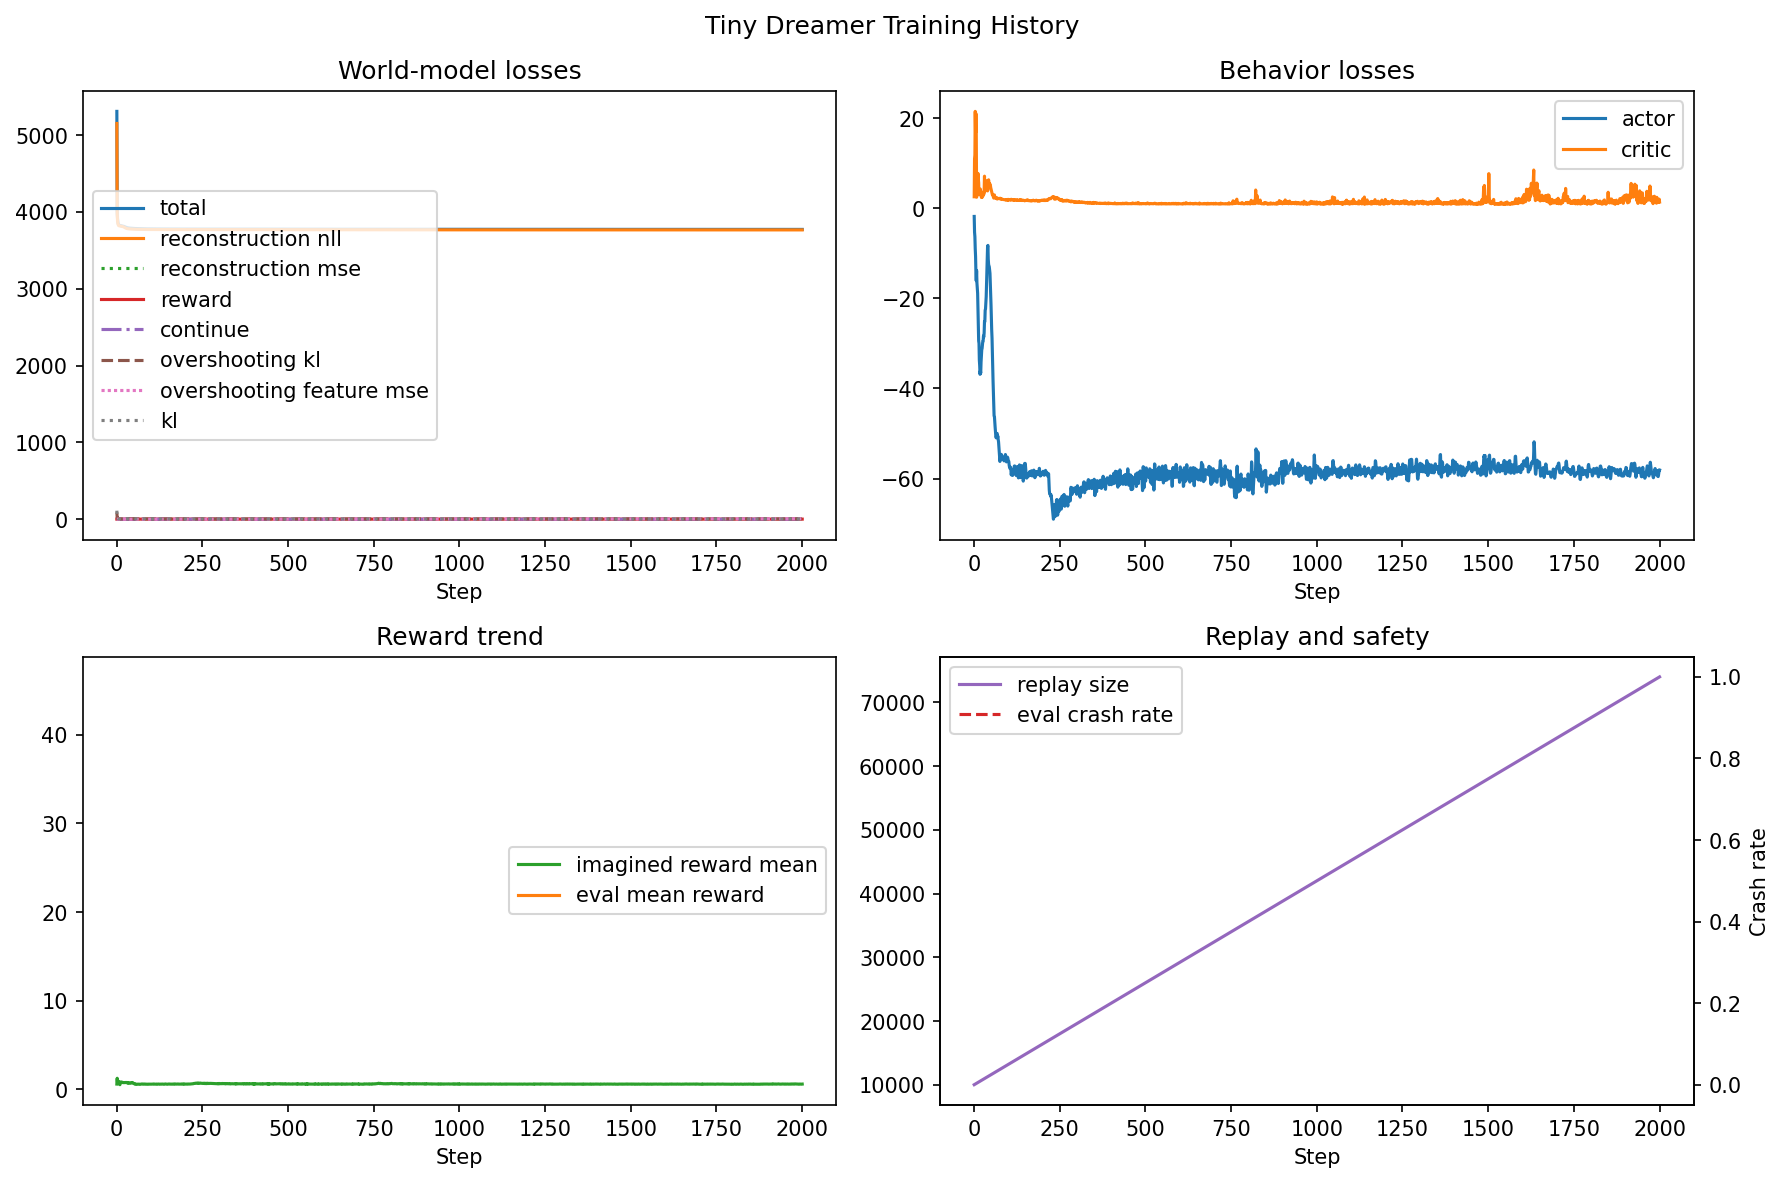

{
  "best_eval_mean_reward": 46.528432830500996,
  "best_eval_reward_step": 250,
  "best_imagined_reward_mean": 1.2580223679542542,
  "best_imagined_reward_step": 2,
  "best_world_model_step": 1999,
  "best_world_model_total_loss": 3772.7059326171875,
  "largest_replay_size": 74000,
  "largest_replay_step": 2000,
  "last_metrics": {
    "behavior/actor_loss": -58.097832679748535,
    "behavior/critic_loss": 1.4078638702630997,
    "behavior/imagined_reward_mean": 0.5993547216057777,
    "behavior/imagined_value_mean": 58.022449016571045,
    "evaluation/crash_rate": 0.4,
    "evaluation/episodes": 10.0,
    "evaluation/mean_reward": 43.90505679903971,
    "evaluation/mean_steps": 75.0,
    "policy_added": 32,
    "replay_size": 74000,
    "step": 2000,
    "warm_start_added": 0,
    "world_model/continue_loss": 0.0004526612385689077,
    "world_model/kl_loss": 3.4903756976127625,
    "world_model/kl_loss_raw": 3.482669770717621,
    "world_model/observation_log_prob": -3766.20297241210

In [6]:
from IPython.display import Image, display
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as _ta_mod

_ta_mod = importlib.reload(_ta_mod)
export_training_history_artifacts = _ta_mod.export_training_history_artifacts

history_artifacts = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

# export_training_history_artifacts returns:
#   history_artifacts['curves']  — multi-panel learning-curves PNG
#   history_artifacts['summary'] — JSON Path with per-metric summary stats
display(Image(filename=str(history_artifacts['curves'])))
analysis_summary = json.loads(history_artifacts['summary'].read_text(encoding='utf-8'))
print(json.dumps(analysis_summary, indent=2))

## 5 · N-step World Model Prediction Evaluation

Given a **seed observation** and the **real actions** recorded in the replay buffer, the world model is asked to predict what the next `EVAL_HORIZON` frames would look like using only the RSSM prior — no observations after the first.

**Protocol:**
1. Encode the seed frame → posterior state (RSSM grounded in reality).
2. Roll forward `EVAL_HORIZON` steps via the prior, applying the recorded actions.
3. Decode each imagined latent to a pixel prediction.
4. Compare predicted vs. actual frames with MSE, PSNR, and SSIM per step.

**Expected pattern:** metrics degrade with step count because autonomous vehicles move unpredictably and the prior accumulates uncertainty. Graceful degradation (slow MSE rise) indicates a well-regularised RSSM; a sharp cliff at step 2–3 indicates the prior has not learned useful multi-step dynamics.

First, load the checkpoint and replay buffer companion file saved by the training loop.

In [7]:
import torch
from tiny_dreamer_highway.data.replay_buffer import ReplayBuffer
from tiny_dreamer_highway.evaluation.policy_rollout import _load_models_from_checkpoint
from tiny_dreamer_highway.evaluation.prediction_eval import (
    evaluate_n_step_predictions,
    evaluate_latent_rollout_consistency,
)
from tiny_dreamer_highway.evaluation.visualization import export_prediction_media_bundle

# ── Load world model and actor weights from the latest checkpoint ────────────
DEVICE = torch.device(config.device if torch.cuda.is_available() else 'cpu')
CKPT_PATH = training_summary.latest_checkpoint
world_model, actor = _load_models_from_checkpoint(CKPT_PATH, config, DEVICE)
print('World model loaded from:', CKPT_PATH)

# ── Restore the replay buffer for ground-truth observation sequences ──────────
# Each checkpoint has a companion replay_{step:05d}.pt in the same directory,
# saved automatically by the training loop.
step_num = int(CKPT_PATH.stem.split('_')[-1])
replay_path = CKPT_PATH.with_name(f'replay_{step_num:05d}.pt')
replay_buffer = ReplayBuffer(capacity=config.replay.capacity)
replay_state = torch.load(replay_path, map_location='cpu', weights_only=False)
replay_buffer.load_state_dict(replay_state)
print(f'Replay buffer restored: {len(replay_buffer):,} transitions  '
      f'(capacity: {replay_buffer.capacity:,})')

World model loaded from: /content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/final_run_001/checkpoints/checkpoint_02000.pt
Replay buffer restored: 74,000 transitions  (capacity: 500,000)


### Checkpoint and Replay Buffer

The checkpoint saved by the training loop contains:
```
step              — environment step count at save time
world_model       — state dict for encoder, RSSM, decoder, reward head, continue head
actor             — state dict for the policy MLP (tanh-Normal output)
critic            — state dict for the value MLP
wm_optimizer      — AdamW / FlashAdamW state for world model parameters
actor_optimizer   — optimizer state for actor
critic_optimizer  — optimizer state for critic
metrics           — list of per-cycle metric dicts logged during training
```

The companion `replay_{step:05d}.pt` is loaded to get real held-out sequences for the prediction evaluation. Using replay data (rather than new rollouts) ensures the evaluation tests generalisation to transitions not seen during the most recent gradient updates.

In [8]:
# ── Sample ground-truth sequences from the replay buffer ─────────────────────
# We request sequences of length (EVAL_HORIZON + 1) so that:
#   observations[:, 0]            → seed frame fed to the encoder
#   observations[:, 1:H+1]        → H actual next frames (prediction targets)
#   actions[:, :H]                 → H actions that produced those transitions

EVAL_HORIZON = 15   # Number of imagination steps
EVAL_BATCH   = 8    # Sequences per evaluation (metrics averaged over this)

seq_batch = replay_buffer.sample_sequence_batch(
    batch_size=EVAL_BATCH,
    sequence_length=EVAL_HORIZON + 1,
)

seed_obs       = torch.as_tensor(seq_batch.observations[:, 0], device=DEVICE)
future_actions = torch.as_tensor(
    seq_batch.actions[:, :EVAL_HORIZON], dtype=torch.float32, device=DEVICE
)
target_obs     = torch.as_tensor(seq_batch.observations[:, 1:EVAL_HORIZON + 1], device=DEVICE)

print(f'seed_obs:       {tuple(seed_obs.shape)}')
print(f'future_actions: {tuple(future_actions.shape)}')
print(f'target_obs:     {tuple(target_obs.shape)}')

# ── Pixel-level n-step prediction evaluation ─────────────────────────────────
# Imagines EVAL_HORIZON steps from the seed frame, then computes MSE/PSNR/SSIM
# per step against the actual frames captured during the same transitions.
n_step_result = evaluate_n_step_predictions(world_model, seed_obs, future_actions, target_obs)

print('\nN-step prediction summary (average over all steps and batch):')
for key, value in n_step_result['summary'].items():
    print(f'  {key}: {value:.4f}')

print('\nPer-step pixel metrics (first 5 steps):')
for item in n_step_result['step_metrics'][:5]:
    step = int(item['step'])
    print(f"  step {step:2d}  MSE={item['mse']:.4f}  "
          f"PSNR={item['psnr']:.2f} dB  SSIM={item['ssim']:.4f}")

seed_obs:       (8, 1, 64, 64)
future_actions: (8, 15, 2)
target_obs:     (8, 15, 1, 64, 64)

N-step prediction summary (average over all steps and batch):
  mse_mean: 0.0395
  psnr_mean: 14.0838
  ssim_mean: 0.1409
  nll_mean: 3844.8091

Per-step pixel metrics (first 5 steps):
  step  1  MSE=0.0417  PSNR=13.80 dB  SSIM=0.0908
  step  2  MSE=0.0492  PSNR=13.08 dB  SSIM=-0.0528
  step  3  MSE=0.0397  PSNR=14.01 dB  SSIM=0.1772
  step  4  MSE=0.0327  PSNR=14.85 dB  SSIM=0.2770
  step  5  MSE=0.0326  PSNR=14.87 dB  SSIM=0.2762


### Prediction Media Export

`export_prediction_media_bundle` produces three files:
- **`metrics_plot.png`** — MSE / PSNR / SSIM curves vs. imagination step.
- **`comparison_grid.png`** — rows = steps, columns = Target | Predicted | Absolute Error (magma colormap).
- **`comparison_video.gif`** — animated version of the grid at 2 fps.

MSE should rise and PSNR should fall with step count. The error column highlights *where* in the frame prediction accuracy is weakest — bright regions around vehicle boundaries are expected; bright errors on empty road indicate decoder quality issues.

Exported prediction artifacts:
  metrics_plot: final_run_001_metrics.png
  comparison_grid: final_run_001_comparison.png
  comparison_video: final_run_001_comparison.gif

Per-step metric curves (MSE / PSNR / SSIM vs imagination step):


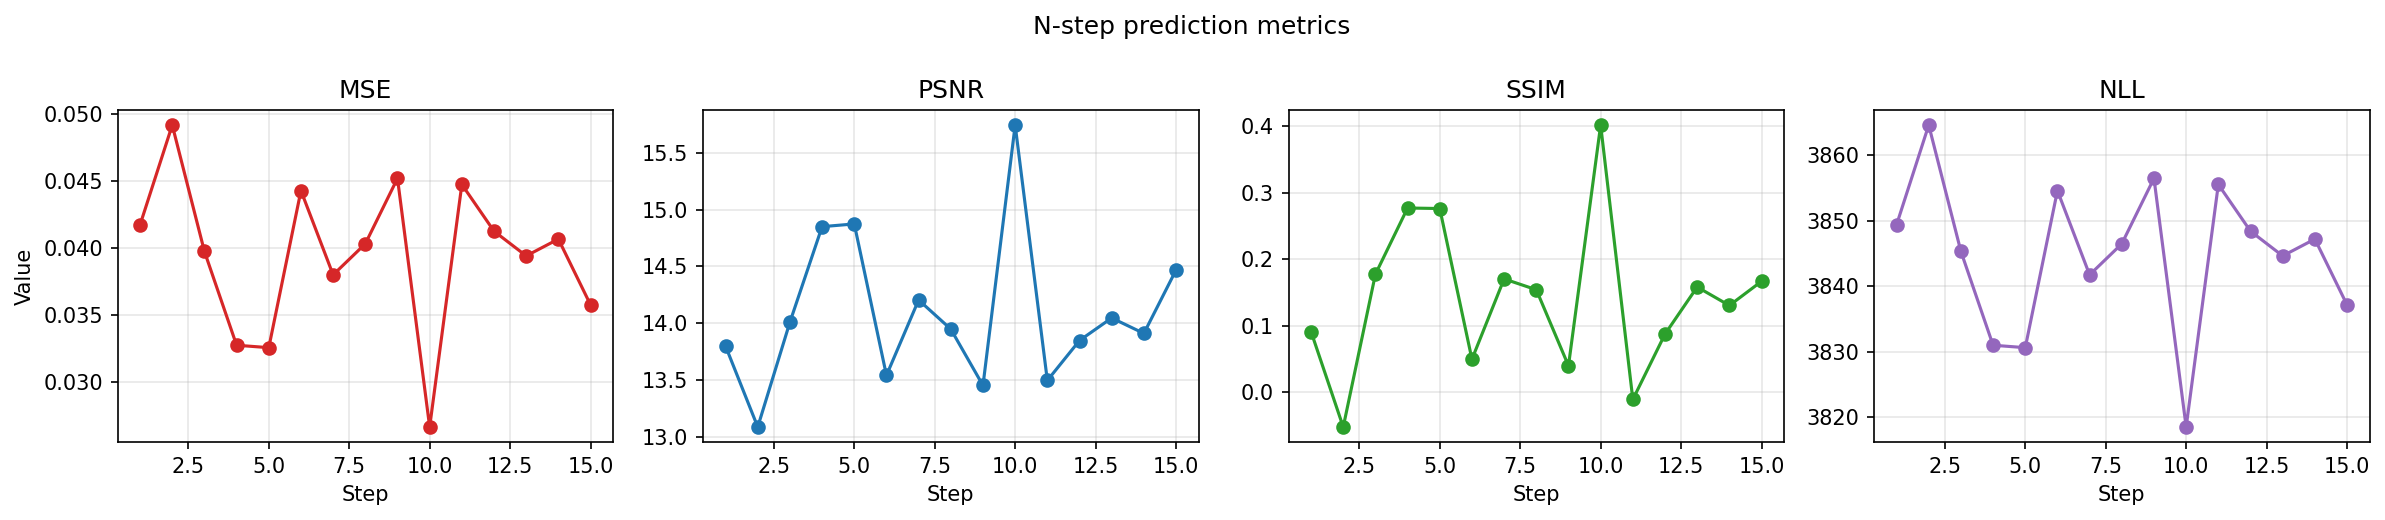


Comparison grid — Target | Predicted | Absolute Error per step:


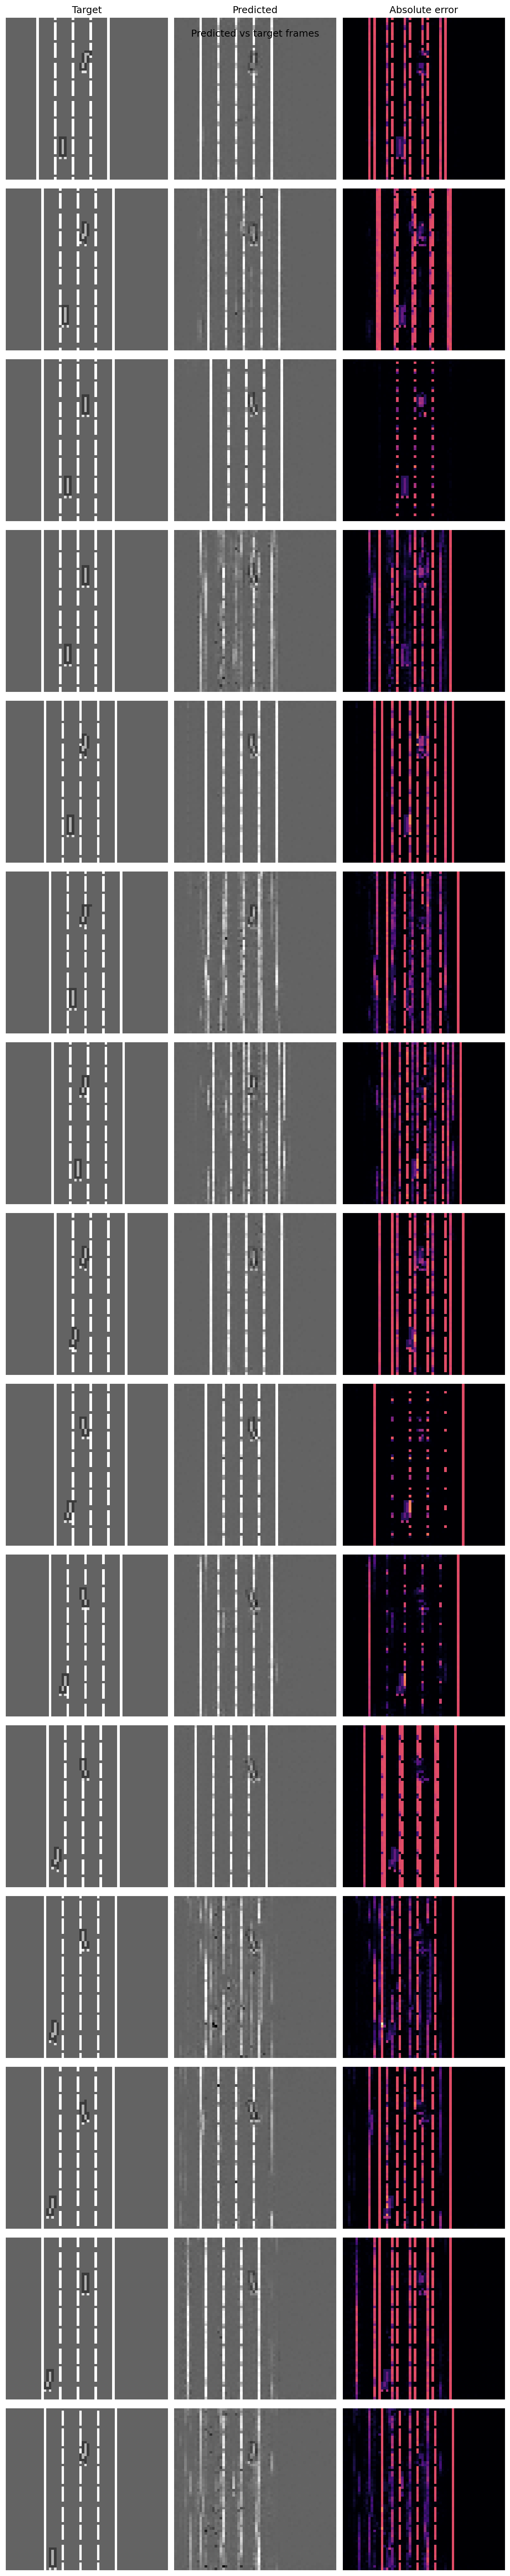


Prediction GIF — animated Target | Predicted | Error:


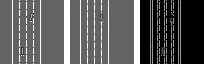

In [9]:
# ── Export side-by-side comparison media ─────────────────────────────────────
# Produces three artifacts per run:
#   metrics_plot     — PNG with per-step MSE / PSNR / SSIM curves
#   comparison_grid  — PNG with rows=steps, cols=(Target | Predicted | Error)
#   comparison_video — animated GIF showing the same layout over time (fps=2
#                      so each step is visible clearly)
from IPython.display import Image, display

pred_media = export_prediction_media_bundle(
    n_step_result['step_metrics'],
    n_step_result['predictions'],
    target_obs,
    RUN_ARTIFACT_ROOT / 'world_model_predictions',
    prefix=RUN_NAME,
    max_steps=EVAL_HORIZON,
    fps=2,
)

print('Exported prediction artifacts:')
for key, path in pred_media.items():
    print(f'  {key}: {path.name}')

print('\nPer-step metric curves (MSE / PSNR / SSIM vs imagination step):')
display(Image(filename=str(pred_media['metrics_plot'])))

print('\nComparison grid — Target | Predicted | Absolute Error per step:')
display(Image(filename=str(pred_media['comparison_grid'])))

print('\nPrediction GIF — animated Target | Predicted | Error:')
display(Image(filename=str(pred_media['comparison_video'])))

### Latent Rollout Consistency

Measures how far the RSSM's **imagined** latent state drifts from the **observation-corrected posterior** state when the same actions are applied.

Two paths from the same starting state:
- **Grounded** — at every step the model receives the real observation and updates via the posterior.
- **Imagined** — the model runs entirely via the prior, no observations after step 0.

`latent_mse` in the table below is the feature-space MSE between these two paths at each step. Low drift means the prior has learned to stay close to what the posterior would be — which is what makes imagination-based planning reliable. The `free_nats = 3.0` threshold is the floor below which the training loss does not penalise prior–posterior divergence.

In [10]:
# ── Latent-space rollout consistency ─────────────────────────────────────────
# Measures how quickly the latent state drifts when the model rolls out purely
# in imagination (no observation correction).  Lower drift → tighter world model.
latent_result = evaluate_latent_rollout_consistency(
    world_model,
    seed_obs,
    future_actions,
    target_obs,
)

print('=== Latent Rollout Consistency ===')
print(f"Summary: {latent_result['summary']}")
print()
print(f"{'Step':>4}  {'Det MSE':>12}  {'Stoch MSE':>12}  {'Feature MSE':>12}  {'Prior-Post KL':>14}")
print('-' * 62)
for s in latent_result['step_metrics']:
    print(
        f"{int(s['step']):>4}  "
        f"{s['deterministic_mse']:>12.6f}  "
        f"{s['stochastic_mse']:>12.6f}  "
        f"{s['feature_mse']:>12.6f}  "
        f"{s['prior_posterior_kl']:>14.6f}"
    )

=== Latent Rollout Consistency ===
Summary: {'deterministic_mse_mean': 0.19067226052284242, 'stochastic_mse_mean': 77.04714762369791, 'feature_mse_mean': 10.215429210662842, 'prior_posterior_kl_mean': 6.413534005482991}

Step       Det MSE     Stoch MSE   Feature MSE   Prior-Post KL
--------------------------------------------------------------
   1      0.000000     45.884998      5.984999        5.138072
   2      0.077252    127.118332     16.647827        6.834618
   3      0.165882     97.516403     12.863775        6.485307
   4      0.197047    129.356339     17.043911        6.591878
   5      0.210825     57.545040      7.689200        5.896423
   6      0.193186     68.082237      9.048278        6.172748
   7      0.214165     74.170982      9.860708        6.495634
   8      0.229636     56.089375      7.515688        7.806956
   9      0.209832     90.781906     12.023580        6.191458
  10      0.248781     69.854019      9.327723        6.016844
  11      0.231597     

## 6 · Agent Driving Demo — Training Environment (Phase A)

Record the trained actor in the **same 4-lane, 28-car environment it was trained in**. At inference the policy runs a real-time RSSM posterior loop: encode frame → observe step → actor mode (tanh of mean, not a sample) → smooth with previous action → scale and execute.

10 episodes, up to 400 steps each. A well-trained agent should accelerate in clear lanes, initiate lane changes ahead of blocked traffic, and avoid collisions.

[demo] episode 1/10 | steps=76 | reward=44.93 | OK | saved final_run_001_train_env_ep01.gif
[demo] episode 2/10 | steps=76 | reward=44.94 | OK | saved final_run_001_train_env_ep02.gif
[demo] episode 3/10 | steps=75 | reward=43.36 | CRASH | saved final_run_001_train_env_ep03.gif
[demo] episode 4/10 | steps=76 | reward=44.96 | OK | saved final_run_001_train_env_ep04.gif
[demo] episode 5/10 | steps=76 | reward=44.97 | OK | saved final_run_001_train_env_ep05.gif
[demo] episode 6/10 | steps=76 | reward=44.89 | OK | saved final_run_001_train_env_ep06.gif
[demo] episode 7/10 | steps=76 | reward=44.94 | OK | saved final_run_001_train_env_ep07.gif
[demo] episode 8/10 | steps=76 | reward=44.84 | OK | saved final_run_001_train_env_ep08.gif
[demo] episode 9/10 | steps=76 | reward=44.95 | OK | saved final_run_001_train_env_ep09.gif
[demo] episode 10/10 | steps=76 | reward=44.95 | OK | saved final_run_001_train_env_ep10.gif
[demo] done | avg_reward=44.77 | summary=final_run_001_train_env_summary.jso

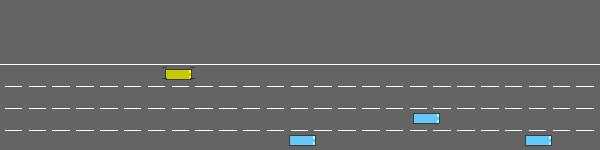

In [11]:
from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos
from IPython.display import Image, display

demo_output_dir = RUN_ARTIFACT_ROOT / 'demo_training_env'

demo_bundle = record_demo_videos(
    config=config,
    checkpoint_path=CKPT_PATH,
    output_dir=demo_output_dir,
    num_episodes=10,
    max_steps=400,
    fps=15,
    seed=42,
    prefix=f'{RUN_NAME}_train_env',
    device=DEVICE,
)

# DemoBundle fields: video_paths (list of Path), results (list of RolloutResult)
ep_rewards = [result.total_reward for result in demo_bundle.results]
ep_lengths = [result.steps for result in demo_bundle.results]

print(f'Episodes recorded : {len(demo_bundle.video_paths)}')
print(f'Mean reward       : {sum(ep_rewards)/len(ep_rewards):.3f}')
print(f'Mean episode len  : {sum(ep_lengths)/len(ep_lengths):.1f}')
print(f'Videos saved to   : {demo_output_dir}')

if demo_bundle.video_paths:
    # Display first episode GIF
    display(Image(filename=str(demo_bundle.video_paths[0])))
else:
    print('No demo GIFs were written; check env.render() / render_mode configuration.')

## 7 · Showcase Demo — 6 Lanes, 45 Cars (Phase B)

Evaluate the **same checkpoint** in a harder environment not seen during training. No fine-tuning — the same weights are deployed directly. The observation is always a 64×64 image, so the CNN encoder processes wider roads the same way it processes the training layout; lane markings simply appear at different pixel positions.

5 episodes, up to 600 steps each. Some reward reduction compared to Phase A is expected due to denser traffic; qualitative behaviour (staying on road, overtaking) should remain intact.

Showcase env: 6 lanes, 45 vehicles
[demo] episode 1/5 | steps=61 | reward=36.18 | OK | saved final_run_001_showcase_ep01.gif
[demo] episode 2/5 | steps=61 | reward=36.17 | OK | saved final_run_001_showcase_ep02.gif
[demo] episode 3/5 | steps=61 | reward=36.05 | OK | saved final_run_001_showcase_ep03.gif
[demo] episode 4/5 | steps=61 | reward=36.18 | OK | saved final_run_001_showcase_ep04.gif
[demo] episode 5/5 | steps=61 | reward=36.25 | OK | saved final_run_001_showcase_ep05.gif
[demo] done | avg_reward=36.16 | summary=final_run_001_showcase_summary.json

Showcase Demo (6 lanes / 45 cars):
  Episodes recorded : 5
  Mean reward       : 36.163
  Mean episode len  : 61.0
  Videos saved to   : /content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/final_run_001/demo_showcase_env


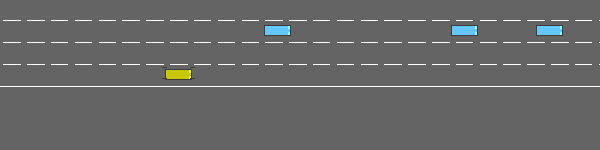

In [12]:
from tiny_dreamer_highway.config import load_experiment_config

showcase_config = load_experiment_config(
    PROJECT_ROOT / 'examples' / 'final_showcase_eval.yaml'
)
print(f"Showcase env: {showcase_config.env.lanes_count} lanes, "
      f"{showcase_config.env.vehicles_count} vehicles")

showcase_output_dir = RUN_ARTIFACT_ROOT / 'demo_showcase_env'

showcase_bundle = record_demo_videos(
    config=showcase_config,
    checkpoint_path=CKPT_PATH,   # same weights as training-env demo
    output_dir=showcase_output_dir,
    num_episodes=5,
    max_steps=600,
    fps=15,
    seed=99,
    prefix=f'{RUN_NAME}_showcase',
    device=DEVICE,
)

sc_rewards = [result.total_reward for result in showcase_bundle.results]
sc_lengths = [result.steps for result in showcase_bundle.results]

print(f'\nShowcase Demo (6 lanes / 45 cars):')
print(f'  Episodes recorded : {len(showcase_bundle.video_paths)}')
print(f'  Mean reward       : {sum(sc_rewards)/len(sc_rewards):.3f}')
print(f'  Mean episode len  : {sum(sc_lengths)/len(sc_lengths):.1f}')
print(f'  Videos saved to   : {showcase_output_dir}')

if showcase_bundle.video_paths:
    display(Image(filename=str(showcase_bundle.video_paths[0])))
else:
    print('No showcase GIFs were written; check env.render() / render_mode configuration.')

## 8 · Submission Bundle

`export_submission_bundle` copies all artifact files into a single directory and writes a `manifest.json` with the bundle name, file list, and any metadata passed in. `create_archive=True` additionally tars and gzips the directory.

| Artifact | Description |
|----------|-------------|
| Training curves PNG | Multi-panel learning-curves figure |
| Checkpoint | World model + actor + critic weights |
| Comparison grid PNG | Target vs. predicted frames per step |
| Prediction metrics plot | MSE / PSNR / SSIM curves |
| Prediction GIF | Animated target / predicted / error |
| Demo videos | Phase A (training env) and Phase B (showcase) first episodes |
| JSON summaries | N-step summary, latent summary, episode stats |

In [13]:
from tiny_dreamer_highway.evaluation.artifact_bundle import export_submission_bundle
import json
import datetime

# ── Compute episode stats from DemoBundle.results ────────────────────────────
ep_rewards = [result.total_reward for result in demo_bundle.results]
sc_rewards = [result.total_reward for result in showcase_bundle.results]

# ── Write lightweight JSON sidecar summaries ──────────────────────────────────
summary_dir = RUN_ARTIFACT_ROOT / 'summaries'
summary_dir.mkdir(parents=True, exist_ok=True)

sidecars = {
    'n_step_summary.json': n_step_result['summary'],
    'latent_summary.json': latent_result['summary'],
    'demo_train_stats.json': {
        'num_episodes': len(demo_bundle.video_paths),
        'mean_reward': sum(ep_rewards) / len(ep_rewards),
        'rewards': ep_rewards,
    },
    'demo_showcase_stats.json': {
        'num_episodes': len(showcase_bundle.video_paths),
        'mean_reward': sum(sc_rewards) / len(sc_rewards),
        'rewards': sc_rewards,
    },
}
for fname, data in sidecars.items():
    (summary_dir / fname).write_text(json.dumps(data, indent=2, default=str))

# ── Bundle all artifacts ──────────────────────────────────────────────────────
# export_submission_bundle copies files and writes a manifest with bundle_name,
# files list, and optional metadata. No SHA digests are generated by default.
artifacts = {
    'training_curves': history_artifacts['curves'],
    'checkpoint': CKPT_PATH,
    'prediction_metrics_plot': pred_media['metrics_plot'],
    'comparison_grid': pred_media['comparison_grid'],
    'prediction_gif': pred_media['comparison_video'],
    'n_step_summary': summary_dir / 'n_step_summary.json',
    'latent_summary': summary_dir / 'latent_summary.json',
    'demo_train_stats': summary_dir / 'demo_train_stats.json',
    'demo_showcase_stats': summary_dir / 'demo_showcase_stats.json',
}
if demo_bundle.video_paths:
    artifacts['demo_train_ep0'] = demo_bundle.video_paths[0]
if showcase_bundle.video_paths:
    artifacts['demo_showcase_ep0'] = showcase_bundle.video_paths[0]

bundle_paths = export_submission_bundle(
    artifacts=artifacts,
    output_dir=DRIVE_ROOT / 'submission',
    bundle_name=f'csc580_final_{RUN_NAME}',
    metadata={
        'run_name': RUN_NAME,
        'timestamp': datetime.datetime.now().isoformat(),
        'lanes': config.env.lanes_count,
        'vehicles': config.env.vehicles_count,
        'n_step_summary': n_step_result['summary'],
        'latent_summary': latent_result['summary'],
        'demo_mean_reward': sum(ep_rewards) / len(ep_rewards),
        'showcase_mean_reward': sum(sc_rewards) / len(sc_rewards),
    },
    create_archive=True,
)

print('=== Submission Bundle ===')
for key, path in bundle_paths.items():
    print(f'  {key}: {path}')
print('\nUpload the .tar.gz to the class submission portal.')

=== Submission Bundle ===
  bundle_dir: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001
  manifest: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/manifest.json
  training_curves: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/final_run_001_curves.png
  checkpoint: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/checkpoint_02000.pt
  prediction_metrics_plot: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/final_run_001_metrics.png
  comparison_grid: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/final_run_001_comparison.png
  prediction_gif: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/final_run_001_comparison.gif
  n_step_summary: /content/drive/MyDrive/CSC_580_Final_Project/submission/csc580_final_final_run_001/n_step_summary.json
  late